![Logo del Curso](/Static/Imgs/UdeC_color_horizontal.jpg)  <!-- Por favor, sube tu logo.png a la carpeta Hidrology_Course -->

Facultrad de Ingenieri Agroicola
Universidad de Concepcion
Curso de Hidrlopgía


Contacto: paulmunoz@udec.cl
paulmunoz.com

Before starting, follow this four steps to run the notebook on Google Colab

https://river-runner-global.samlearner.com/

Step 1. Clone GitHub repository with notebooks and data for the course

In [46]:
!git clone -- https://github.com/paulmunozpauta/Hidrology_Course

Cloning into 'Hidrology_Course'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 57 (delta 5), reused 6 (delta 1), pack-reused 38 (from 1)
Receiving objects: 100% (57/57), 57.29 MiB | 27.12 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [2]:
ls

Hidrology_Course/  sample_data/


Step 2: Let's move to the cloned folder


In [3]:
%cd Hidrology_Course

/content/Hidrology_Course


In [4]:
ls

01_Delimitacion_cuenca.ipynb  Data/  README.md


# Delimitación de cuenca hidrográfica

Este notebook permite delimitar una cuenca hidrográfica a partir de:

- un DEM (`dem.tif`)
- un punto de salida definido con coordenadas `lon/lat`

Está pensado para ejecutarse en **Google Colab** con librerías comunes y código simple, claro y bien comentado.


In [5]:
# Instalar librerías necesarias
!pip -q install leafmap pysheds rasterio geopandas shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.8/666.8 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.7 MB/s eta 0:00:00


In [18]:
# Importar librerías
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
import geopandas as gpd
from pysheds.grid import Grid
import leafmap.foliumap as leafmap
from rasterio.plot import show
from rasterio.enums import Resampling
from rasterio.warp import transform
from rasterio.plot import show
from shapely.geometry import Point


## 1. Mostrar mapa base

Usa este mapa solo para ubicar visualmente la zona de estudio y elegir el punto de salida.
En esta primera versión, las coordenadas del punto se ingresan manualmente.


In [8]:
# Crear mapa base
m = leafmap.Map()
m.add_basemap("OpenTopoMap")
m

In [ ]:
# Crear mapa base en un punto específico
m = leafmap.Map(center=[-36.59433389487894, -72.08269046506874], zoom=15)
m.add_basemap("OpenTopoMap")
m

## 2. Definir la ruta del DEM

Antes de ejecutar esta parte, sube a Colab un archivo llamado `dem.tif`.


DEM oficial Hidrografía Chile (DGA)
https://lineasdebasepublicas.mma.gob.cl/datos_abiertos/dataset/hidrosfera/resource/0c159d9e-4378-40f0-80da-240aad755a21?utm_source=chatgpt.com

In [9]:
ls

01_Delimitacion_cuenca.ipynb  Data/  README.md


2) ruta del DEM original

In [10]:
# Ruta del DEM
dem_path = "Data/Ñuble/REGION_NUBLE_1.jp2"

if not os.path.exists(dem_path):
    raise FileNotFoundError(
        "No se encontró el archivo DEM"
    )

print("DEM encontrado:", dem_path)



DEM encontrado: Data/Ñuble/REGION_NUBLE_1.jp2


revisar resolución

In [11]:
with rasterio.open(dem_path) as src:
    print("Resolución original (x, y):", src.res)
    print("Ancho (pixeles):", src.width)
    print("Alto (pixeles):", src.height)
    print("CRS:", src.crs)

Resolución original (x, y): (0.00011559404618781494, 0.00011559404618781474)
Ancho (pixeles): 18547
Alto (pixeles): 12783
CRS: GEOGCS["GCS_SIRGAS_Chile",DATUM["SIRGAS-Chile",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1064"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


≈ 237 millones de píxeles

3) crear DEM de baja resolución

In [12]:
dem_lowres_path = "Data/Ñuble/REGION_NUBLE_1_lowres.tif"

scale_factor = 8   # prueba también 5 o 10

with rasterio.open(dem_path) as src:
    data = src.read(
        1,
        out_shape=(
            int(src.height / scale_factor),
            int(src.width / scale_factor)
        ),
        resampling=Resampling.average
    )

    transform_lowres = src.transform * src.transform.scale(
        (src.width / data.shape[1]),
        (src.height / data.shape[0])
    )

    profile = src.profile.copy()
    profile.update({
        "driver": "GTiff",
        "height": data.shape[0],
        "width": data.shape[1],
        "transform": transform_lowres,
        "dtype": data.dtype
    })

    with rasterio.open(dem_lowres_path, "w", **profile) as dst:
        dst.write(data, 1)

print("DEM lowres guardado en:", dem_lowres_path)

DEM lowres guardado en: Data/Ñuble/REGION_NUBLE_1_lowres.tif


4) revisar resolución original y nueva

In [13]:
with rasterio.open(dem_path) as src:
    print("Resolución original:", src.res)
    print("Dimensiones originales:", src.width, "x", src.height)

with rasterio.open(dem_lowres_path) as src:
    print("Resolución lowres:", src.res)
    print("Dimensiones lowres:", src.width, "x", src.height)

Resolución original: (0.00011559404618781494, 0.00011559404618781474)
Dimensiones originales: 18547 x 12783
Resolución lowres: (0.0009249019735312354, 0.0009252590434682753)
Dimensiones lowres: 2318 x 1597


5) mostrar DEM lowres

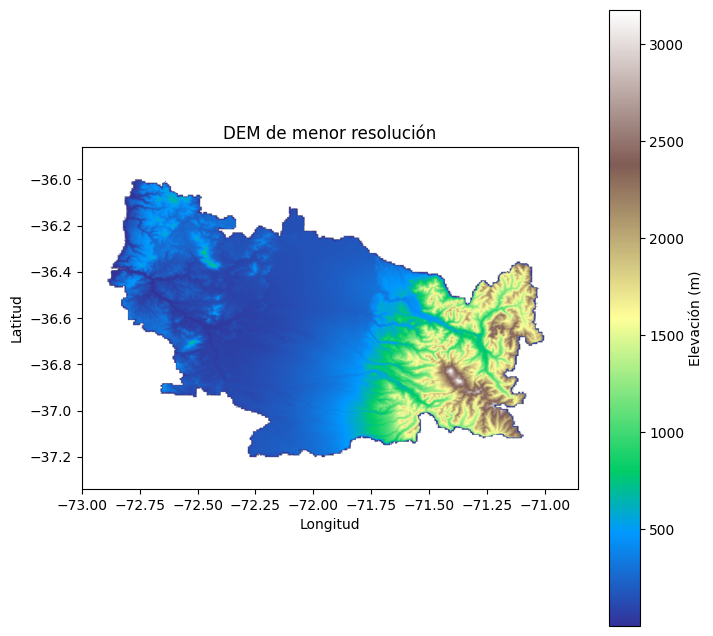

In [44]:
import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np

with rasterio.open(dem_lowres_path) as src:
    dem_plot = src.read(1).astype(float)

    if src.nodata is not None:
        dem_plot[dem_plot == src.nodata] = np.nan

    fig, ax = plt.subplots(figsize=(8, 8))

    # usar una paleta mejor para elevación
    im = ax.imshow(
        dem_plot,
        cmap="terrain",   # buena para topografía
        extent=(
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        )
    )

    ax.set_title("DEM de menor resolución")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

    # agregar colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Elevación (m)")

    plt.show()

6) preparar DEM para análisis hidrológico

In [19]:
grid = Grid.from_raster(dem_lowres_path)
dem = grid.read_raster(dem_lowres_path)
print("Rellenando depresiones...")
dem_filled = grid.fill_depressions(dem)
print("Resolviendo zonas planas...")
dem_inflated = grid.resolve_flats(dem_filled)
print("Calculando dirección de flujo...")
fdir = grid.flowdir(dem_inflated)
print("Calculando acumulación...")
acc = grid.accumulation(fdir)
print("DEM listo para el análisis hidrológico.")

Rellenando depresiones...
Resolviendo zonas planas...
Calculando dirección de flujo...
Calculando acumulación...
DEM listo para el análisis hidrológico.


## 7. Definir el punto de salida

Reemplaza estos valores por las coordenadas del punto ubicado sobre el río.


In [29]:
# Coordenadas del punto de salida
approximate_lon = -72.5
approximate_lat = -36.6
point = Point(approximate_lon, approximate_lat)
print(f"Punto de salida: lon={approximate_lon}, lat={approximate_lat}")

Punto de salida: lon=-72.5, lat=-36.6


# 2. CONVERTIR EL PUNTO AL CRS DEL DEM


In [30]:
with rasterio.open(dem_lowres_path) as src:
    x_out, y_out = transform("EPSG:4326", src.crs, [approximate_lon], [approximate_lat])
    x_out = x_out[0]
    y_out = y_out[0]

print("\nPunto en CRS del DEM:")
print("x =", x_out)
print("y =", y_out)



Punto en CRS del DEM:
x = -72.5
y = -36.6


3) ajustar al río más cercano

In [31]:
def snap_to_high_accumulation(dem_path, acc, x, y, search_radius=10):
    """
    Ajusta un punto al píxel cercano con mayor acumulación de flujo.

    Parámetros
    ----------
    dem_path : str
        Ruta del DEM usado en pysheds.
    acc : ndarray
        Matriz de acumulación de flujo.
    x, y : float
        Coordenadas del punto en el CRS del DEM.
    search_radius : int
        Radio de búsqueda en píxeles.

    Retorna
    -------
    snapped_x, snapped_y : float
        Coordenadas ajustadas.
    snapped_row, snapped_col : int
        Índices del píxel ajustado.
    """
    with rasterio.open(dem_path) as src:
        row, col = src.index(x, y)

        row_min = max(0, row - search_radius)
        row_max = min(acc.shape[0], row + search_radius + 1)
        col_min = max(0, col - search_radius)
        col_max = min(acc.shape[1], col + search_radius + 1)

        window_acc = acc[row_min:row_max, col_min:col_max]

        if window_acc.size == 0:
            raise ValueError("La ventana de búsqueda está vacía.")

        local_idx = np.unravel_index(np.nanargmax(window_acc), window_acc.shape)

        snapped_row = row_min + local_idx[0]
        snapped_col = col_min + local_idx[1]

        snapped_x, snapped_y = src.xy(snapped_row, snapped_col)

    return snapped_x, snapped_y, snapped_row, snapped_col
snapped_x, snapped_y, snapped_row, snapped_col = snap_to_high_accumulation(
    dem_lowres_path,
    acc,
    x_out,
    y_out,
    search_radius=12
)

print("\nPunto ajustado a máxima acumulación cercana:")
print("x =", snapped_x)
print("y =", snapped_y)
print("fila =", snapped_row)
print("columna =", snapped_col)


Punto ajustado a máxima acumulación cercana:
x = -72.51105555119776
y = -36.61083543702425
fila = 810
columna = 529


# 5. VISUALIZAR ACUMULACIÓN Y PUNTO AJUSTADO

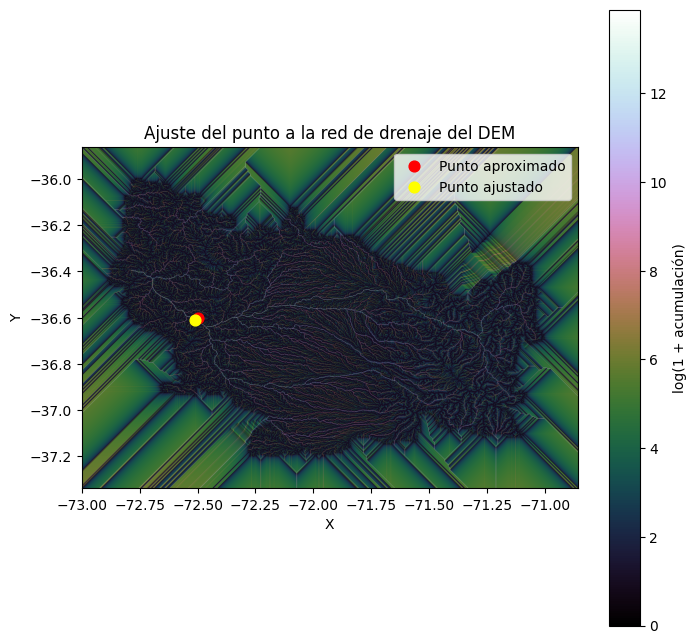

In [32]:
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    np.log1p(acc),
    extent=grid.extent,
    cmap="cubehelix"
)

ax.scatter(x_out, y_out, s=60, c="red", label="Punto aproximado")
ax.scatter(snapped_x, snapped_y, s=60, c="yellow", label="Punto ajustado")

ax.set_title("Ajuste del punto a la red de drenaje del DEM")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

plt.colorbar(im, ax=ax, label="log(1 + acumulación)")
plt.show()


# 6. DELIMITAR CUENCA USANDO EL PUNTO AJUSTADO


In [33]:
catch = grid.catchment(
    x=snapped_col,
    y=snapped_row,
    fdir=fdir,
    xytype="index"
)

print("Cuenca delimitada correctamente.")

Cuenca delimitada correctamente.


11) visualizar la cuenca


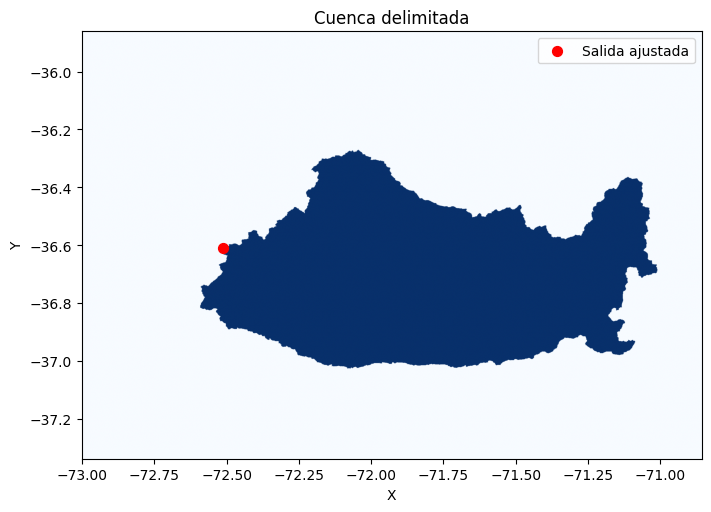

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(catch, extent=grid.extent, cmap="Blues")
ax.scatter(snapped_x, snapped_y, s=50, c="red", label="Salida ajustada")

ax.set_title("Cuenca delimitada")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

plt.show()

Una vez que ya tienes la cuenca delimitada, puedes calcular varias características físicas

In [35]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
import matplotlib.pyplot as plt

# =========================================================
# 1. CONVERTIR LA MÁSCARA DE CUENCA A POLÍGONO
# =========================================================
mask = catch.astype(np.uint8)

results = shapes(mask, mask=mask > 0, transform=grid.affine)
geoms = [shape(geom) for geom, value in results if value == 1]

if len(geoms) == 0:
    raise ValueError("No se pudo generar el polígono de la cuenca.")

basin_gdf = gpd.GeoDataFrame(geometry=geoms, crs=grid.crs)
basin_gdf = basin_gdf.dissolve().explode(index_parts=False).reset_index(drop=True)

print("Polígono de cuenca generado correctamente.")

Polígono de cuenca generado correctamente.


In [36]:
# =========================================================
# 2. CALCULAR ÁREA Y PERÍMETRO
# =========================================================
# Importante:
# si el CRS está en metros, el área sale en m2 y el perímetro en m.
# si está en grados, hay que reproyectar.

if basin_gdf.crs.is_geographic:
    basin_metric = basin_gdf.to_crs(basin_gdf.estimate_utm_crs())
else:
    basin_metric = basin_gdf.copy()

basin_geom = basin_metric.geometry.iloc[0]

area_m2 = basin_geom.area
area_km2 = area_m2 / 1e6

perimeter_m = basin_geom.length
perimeter_km = perimeter_m / 1000

print(f"Área: {area_km2:.2f} km²")
print(f"Perímetro: {perimeter_km:.2f} km")

Área: 7482.32 km²
Perímetro: 684.01 km


In [38]:
# =========================================================
# 3. CALCULAR ESTADÍSTICAS DE ELEVACIÓN Y PENDIENTE
# =========================================================
with rasterio.open(dem_lowres_path) as src:
    dem = src.read(1).astype(float)
    transform = src.transform
    res_x, res_y = src.res

    if src.nodata is not None:
        dem[dem == src.nodata] = np.nan

# usar solo celdas dentro de la cuenca
dem_basin = np.where(catch > 0, dem, np.nan)

elev_min = np.nanmin(dem_basin)
elev_max = np.nanmax(dem_basin)
elev_mean = np.nanmean(dem_basin)
elev_std = np.nanstd(dem_basin)

print(f"Elevación mínima: {elev_min:.2f} m")
print(f"Elevación máxima: {elev_max:.2f} m")
print(f"Elevación media: {elev_mean:.2f} m")
print(f"Desviación estándar de elevación: {elev_std:.2f} m")

# pendiente a partir del gradiente del DEM
# ojo: res_y puede salir negativo en algunos raster, por eso usamos abs
dx = abs(res_x)
dy = abs(res_y)

grad_y, grad_x = np.gradient(dem, dy, dx)
slope_rad = np.arctan(np.sqrt(grad_x**2 + grad_y**2))
slope_deg = np.degrees(slope_rad)

slope_basin = np.where(catch > 0, slope_deg, np.nan)

slope_mean = np.nanmean(slope_basin)
slope_min = np.nanmin(slope_basin)
slope_max = np.nanmax(slope_basin)

print(f"Pendiente media: {slope_mean:.2f} grados")
print(f"Pendiente mínima: {slope_min:.2f} grados")
print(f"Pendiente máxima: {slope_max:.2f} grados")

Elevación mínima: 19.00 m
Elevación máxima: 3177.00 m
Elevación media: 683.84 m
Desviación estándar de elevación: 666.65 m
Pendiente media: 88.43 grados
Pendiente mínima: 0.00 grados
Pendiente máxima: 90.00 grados


In [39]:
# =========================================================
# 4. LONGITUD MÁXIMA Y ANCHO MEDIO
# =========================================================
minx, miny, maxx, maxy = basin_geom.bounds

length_max_m = max(maxx - minx, maxy - miny)
length_max_km = length_max_m / 1000

# ancho medio aproximado = área / longitud máxima
mean_width_m = area_m2 / length_max_m
mean_width_km = mean_width_m / 1000

print(f"Longitud máxima aproximada: {length_max_km:.2f} km")
print(f"Ancho medio aproximado: {mean_width_km:.2f} km")

Longitud máxima aproximada: 141.02 km
Ancho medio aproximado: 53.06 km


In [40]:
# =========================================================
# 5. ÍNDICES MORFOMÉTRICOS
# =========================================================
# factor de forma
form_factor = area_m2 / (length_max_m ** 2)

# índice de compacidad de Gravelius
gravelius = perimeter_m / (2 * np.sqrt(np.pi * area_m2))

# circularidad
circularity = (4 * np.pi * area_m2) / (perimeter_m ** 2)

print(f"Factor de forma: {form_factor:.3f}")
print(f"Índice de compacidad (Gravelius): {gravelius:.3f}")
print(f"Índice de circularidad: {circularity:.3f}")

Factor de forma: 0.376
Índice de compacidad (Gravelius): 2.231
Índice de circularidad: 0.201


In [41]:
# =========================================================
# 6. RESUMEN EN TABLA
# =========================================================
import pandas as pd

basin_summary = pd.DataFrame({
    "Parámetro": [
        "Área",
        "Perímetro",
        "Elevación mínima",
        "Elevación máxima",
        "Elevación media",
        "Pendiente media",
        "Pendiente mínima",
        "Pendiente máxima",
        "Longitud máxima aprox.",
        "Ancho medio aprox.",
        "Factor de forma",
        "Índice de compacidad",
        "Índice de circularidad"
    ],
    "Valor": [
        area_km2,
        perimeter_km,
        elev_min,
        elev_max,
        elev_mean,
        slope_mean,
        slope_min,
        slope_max,
        length_max_km,
        mean_width_km,
        form_factor,
        gravelius,
        circularity
    ],
    "Unidad": [
        "km²",
        "km",
        "m",
        "m",
        "m",
        "grados",
        "grados",
        "grados",
        "km",
        "km",
        "-",
        "-",
        "-"
    ]
})

basin_summary

,Parámetro,Valor,Unidad
0,Área,7482.324225,km²
1,Perímetro,684.005958,km
2,Elevación mínima,19.000000,m
3,Elevación máxima,3177.000000,m
4,Elevación media,683.839242,m
5,Pendiente media,88.425747,grados
6,Pendiente mínima,0.000000,grados
7,Pendiente máxima,89.999940,grados
8,Longitud máxima aprox.,141.023210,km
9,Ancho medio aprox.,53.057395,km


In [42]:
output_csv = "Data/Ñuble/Caracteristicas_cuenca.csv"
basin_summary.to_csv(output_csv, index=False)
print("Resumen guardado en:", output_csv)

Resumen guardado en: Data/Ñuble/Caracteristicas_cuenca.csv
